# LightGCN: recommendations through a graph

## Introduction

On a film platform, every like links a user to a film. You liked Psycho. So did hundreds of other users, who liked other films, which were liked by other users... The likes form a web. Let's draw it. Every user is a dot, every film is a box, and every like is a line between a user and a film. This drawing is called a **graph**:

![A piece of the MovieLens graph: 18 users and 22 films, with a line for every like. The horror films gather around our horror fan, the children's films on the other side.](images/likes_graph_network.svg)

This is only a small piece of MovieLens: 18 users and 22 films. We placed them so that the lines pull their two ends together. Nobody told the graph what a horror film is. Yet the horror films gather on one side, around a horror fan, and the children's films on the other. Users with the same taste like the same films, so they end up close.

How do we recommend with it? Let's zoom on two users only: you, and another user, A.

![You and A both liked Psycho and The Birds. A also liked The Shining. Three steps along the lines lead from you to The Shining.](images/likes_graph.svg)

To go from you to The Shining, we follow three lines: you → Psycho → A → The Shining. A liked the same films as you, so A is one of your **nearest neighbors**. Recommending what your nearest neighbors liked is a classic recommender (chapter 3), and here it is a walk on the drawing. And the further we walk, the more of the graph we reach.

**LightGCN** takes this idea and adds learning: *learn a vector for every user and every film, and let these vectors travel along the lines of the graph.*

## Example scenario

We use **MovieLens 100K**, a classic dataset from the [GroupLens research group](https://grouplens.org/datasets/movielens/100k/): 943 users gave 100,000 ratings, from 1 to 5, to 1,682 films. A small `movielens` module downloads it and reads the files. First, the films and the ratings:

In [1]:
from recommendationsystems.movielens import load_movies, load_ratings

_, titles, _ = load_movies()  # only the titles, to read the recommendations
ratings = load_ratings()
print(ratings[:5])

[[259 254   4]
 [259 285   4]
 [259 297   4]
 [259 184   4]
 [259 172   4]]


Each row is one rating: a user, a film, and a rating from 1 to 5, sorted by time. A rating of 4 or 5 means that the user **liked** the film.

We follow one user through the chapter, user 366. Among the films they liked: Psycho, The Birds, Scream, Evil Dead II, Braindead... A horror fan! Keep them in mind, we will check what each recommender suggests to them.

To know if a recommender is good, we cannot ask the real users. So we **hide the last 10 ratings** of each user, as if they had not happened yet. The recommender only sees the rest, the **history**, and suggests 10 films. Then we reveal the hidden ratings: if at least one of the 10 films was liked later, it is a **hit**!

In [2]:
import numpy as np
from recommendationsystems.movielens import MovieId, UserId

fan = 366
history = {}  # key: user, value: array of (film, rating) the recommender can see
liked_later = {}  # key: user, value: set of hidden films the user liked
for user in np.unique(ratings[:, 0]):
    user_ratings = ratings[ratings[:, 0] == user]
    history[user] = user_ratings[:-10, 1:]
    liked_later[user] = {movie for movie, rating in user_ratings[-10:, 1:] if rating >= 4}

def liked(user: UserId) -> np.ndarray:
    return history[user][history[user][:, 1] >= 4, 0]

Every recommender works the same way: it gives **a score to every film**, and we keep the 10 films with the best score, skipping the films the user has already seen. We test it on every user who liked at least one film before and after the cut. The **hit rate** is the share of these users who got a hit.

In [3]:
from collections.abc import Callable

def top_10(scores: np.ndarray, user: UserId) -> list[MovieId]:
    """Return the 10 best-scored films that the user has not seen yet."""
    seen = set(history[user][:, 0])
    best_first = np.argsort(-scores, kind="stable")  # all films, best score first
    return [int(movie) for movie in best_first if movie not in seen][:10]

test_users = [user for user in history if liked_later[user] and len(liked(user))]

def evaluate(reco: Callable[[UserId], list[MovieId]]) -> float:
    hits = [bool(set(reco(user)) & liked_later[user]) for user in test_users]
    return sum(hits) / len(hits)

Two reference points: random films, and popular films (the films with the most likes, the same list for everybody):

In [4]:
rng = np.random.default_rng(21)

def random_reco(user: UserId) -> list[MovieId]:
    return top_10(rng.random(len(titles)), user)

likes = np.bincount(np.concatenate([liked(user) for user in history]), minlength=len(titles))

def popular_reco(user: UserId) -> list[MovieId]:
    return top_10(likes, user)

print(f"Random: {evaluate(random_reco):.3f}")
print(f"Popular: {evaluate(popular_reco):.3f}")

Random: 0.034
Popular: 0.346


The scores to beat, from the other chapters:
- 0.518 for the **nearest neighbors** (chapter 3): find the 40 users whose likes are closest to yours, and recommend what they liked,
- 0.513 for the **two towers** (chapter 4): a learned vector for every user and every film,
- 0.525 for **SASRec** (chapter 5): a model that reads the last 20 films of a user, in order.

## The likes graph

### a. Let's build it

The graph fits in the **likes table**: one row per user, one column per film, and a 1 when the user liked the film. Every 1 is a line between a user and a film.

In [5]:
n_users = ratings[:, 0].max() + 1  # user ids start at 1, so row 0 stays empty
likes_table = np.zeros((n_users, len(titles)))
for user in history:
    likes_table[user, liked(user)] = 1

print(f"{n_users - 1} users, {len(titles)} films, {likes_table.sum():.0f} lines")

943 users, 1682 films, 50232 lines


### b. Let's walk the graph

Let's follow the lines, starting from our fan, like in the drawing:
1. from our fan to the films they liked,
2. from these films to the users who liked them,
3. from these users to the films they liked.

The score of a film is the number of walks that end on it. No need to walk by hand: each step is a product with the likes table, or with its transpose to go back from the films to the users.

In [6]:
def walk_reco(user: UserId) -> list[MovieId]:
    return top_10(likes_table[user] @ likes_table.T @ likes_table, user)

for movie in walk_reco(fan):
    print(titles[movie])

Star Wars (1977)
Raiders of the Lost Ark (1981)
Fargo (1996)
Empire Strikes Back, The (1980)
Return of the Jedi (1983)
Fugitive, The (1993)
Godfather, The (1972)
Alien (1979)
Princess Bride, The (1987)
Usual Suspects, The (1995)


### c. How does this recommender perform?

In [7]:
print(f"Walks: {evaluate(walk_reco):.3f}")

Walks: 0.395


Better than popular films, but far from the nearest neighbors. And look at the list: Star Wars, Raiders of the Lost Ark, Fargo... The popular films again!

It makes sense: a popular film has hundreds of lines, so hundreds of walks end on it. And a user who liked 300 films opens far more walks than a user who liked 20, so they weigh much more in the vote. The crowd drowns out the few users who really share our fan's taste.

## Fair walks: busy nodes speak softer

### a. Let's shrink the busy lines

The fix: a line counts less when it touches a busy user or a popular film. The weight of the line between user $u$ and film $f$ becomes:

$$
\text{weight}(u, f) = \frac{1}{\sqrt{\text{likes of } u} \times \sqrt{\text{likes of } f}}
$$

A line between a user with 4 likes and a film with 25 likes weighs $\frac{1}{2 \times 5} = 0.1$. A line between a user with 100 likes and a film with 400 likes weighs $\frac{1}{10 \times 20} = 0.005$: twenty times less.

In code, we divide each row of the likes table by the square root of its number of likes, and each column too. The `np.maximum` avoids a division by 0 for the users and films without any like.

In [8]:
user_likes = likes_table.sum(axis=1, keepdims=True)
film_likes = likes_table.sum(axis=0, keepdims=True)
graph = likes_table / np.sqrt(np.maximum(user_likes, 1)) / np.sqrt(np.maximum(film_likes, 1))

### b. Let's walk again

Same walk, on the weighted graph:

In [9]:
def fair_walk_reco(user: UserId) -> list[MovieId]:
    return top_10(graph[user] @ graph.T @ graph, user)

for movie in fair_walk_reco(fan):
    print(titles[movie])

Shining, The (1980)
Natural Born Killers (1994)
Alien (1979)
Fargo (1996)
Aliens (1986)
Star Wars (1977)
Lord of Illusions (1995)
Raiders of the Lost Ark (1981)
Empire Strikes Back, The (1980)
Blade Runner (1982)


The Shining comes first, and our fan liked it later: a hit! Alien, Aliens, Lord of Illusions: the list looks like our fan again.

### c. How does this recommender perform?

In [10]:
print(f"Fair walks: {evaluate(fair_walk_reco):.3f}")

Fair walks: 0.476


A big jump, and we did not train anything: three matrix products on a weighted table.

But these walks only count lines: they learn nothing. Models that learn a vector for every user and every film usually do better than counting. Can we have both?

## LightGCN: vectors that walk the graph

### a. Let's give each node a vector

Every user and every film gets a vector of 32 numbers, learned during training. We call it the vector of **step 0**. As usual, the score of a film for a user is the dot product of their vectors: high when they point the same way.

Now, let's make these vectors walk the graph:
- at **step 1**, the vector of a user is the weighted sum of the vectors of the films they liked. The vector of a film is the weighted sum of the vectors of the users who liked it,
- at **step 2**, we do it again: the user now receives what their films received from the other users.

The final vector of a node is the **average** of its vectors at each step:

![Step 0 is the user's own vector, step 1 mixes the vectors of the films they liked, step 2 mixes the vectors of the users who liked these films. The final vector is the average of the three.](images/lightgcn_steps.svg)

Each step is a product with our weighted graph, exactly like our fair walks. The difference: what walks along the lines is no longer a count, but a vector learned during training.

That is the whole model! The "Light" in LightGCN means that it only keeps this walk: other graph models add layers of neural network between the steps, and LightGCN showed that they are not needed.

### b. Let's build the model

The vectors of step 0 are a table, with one row per user, and another table for the films. PyTorch has a shortcut for such a table: `nn.Embedding`. The rest is the walk:

In [11]:
import torch
from torch import nn

graph_tensor = torch.tensor(graph, dtype=torch.float32)

class LightGCN(nn.Module):
    def __init__(self, steps: int, size: int = 32):
        super().__init__()
        self.steps = steps
        self.user_table = nn.Embedding(n_users, size)
        self.film_table = nn.Embedding(len(titles), size)
        nn.init.normal_(self.user_table.weight, std=0.1)  # small random vectors to start
        nn.init.normal_(self.film_table.weight, std=0.1)

    def vectors(self) -> tuple[torch.Tensor, torch.Tensor]:
        """Return the final vector of every user and every film."""
        users, films = self.user_table.weight, self.film_table.weight
        user_steps, film_steps = [users], [films]
        for _ in range(self.steps):
            users, films = graph_tensor @ films, graph_tensor.T @ users  # one step along the lines
            user_steps.append(users)
            film_steps.append(films)
        return torch.stack(user_steps).mean(dim=0), torch.stack(film_steps).mean(dim=0)

    def forward(self, users: torch.Tensor) -> torch.Tensor:
        """Return the score of every film for each user."""
        user_vectors, film_vectors = self.vectors()
        return user_vectors[users] @ film_vectors.T

Notice: with `steps=0`, the vectors do not walk at all. Each user and each film keeps its own learned vector, nothing more (the two towers of chapter 4, with IDs only).

### c. Let's train it

For each like, the model must guess the liked film among the 1,682 films. The **softmax** turns the scores into probabilities, and the loss is the **cross-entropy**: it is small when the right film gets a high probability.

In [12]:
liked_pairs = torch.tensor([(user, movie) for user in history for movie in liked(user)])

def train(model: LightGCN, epochs: int = 10) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(epochs):  # an epoch is one pass over all the likes
        for batch in liked_pairs[torch.randperm(len(liked_pairs))].split(512):
            users, films = batch.T
            loss = nn.functional.cross_entropy(model(users), films)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

torch.manual_seed(21)
lightgcn = LightGCN(steps=2)
train(lightgcn)

### d. Let's recommend

In [13]:
def recommender(model: LightGCN) -> Callable[[UserId], list[MovieId]]:
    with torch.no_grad():
        all_scores = model(torch.arange(n_users)).numpy()
    return lambda user: top_10(all_scores[user], user)

lightgcn_reco = recommender(lightgcn)
for movie in lightgcn_reco(fan):
    print(titles[movie])

Natural Born Killers (1994)
Shining, The (1980)
Alien (1979)
Lord of Illusions (1995)
Interview with the Vampire (1994)
Aliens (1986)
Wes Craven's New Nightmare (1994)
Tales From the Crypt Presents: Demon Knight (1995)
In the Mouth of Madness (1995)
Mary Shelley's Frankenstein (1994)


Horror everywhere: Natural Born Killers, Alien, In the Mouth of Madness, Wes Craven's New Nightmare... The popular films are gone, and The Shining is still there: a hit!

### e. How does this recommender perform?

In [14]:
print(f"LightGCN: {evaluate(lightgcn_reco):.3f}")

LightGCN: 0.511


Better than the fair walks, and close to the scores to beat. But is it thanks to the walk, or only thanks to the learned vectors? Let's check.

### f. How many steps?

Why 2 steps? Let's try from 0 (no walk at all) to 3:

Steps: 0, hit rate: 0.479


Steps: 1, hit rate: 0.491


Steps: 2, hit rate: 0.511


Steps: 3, hit rate: 0.506


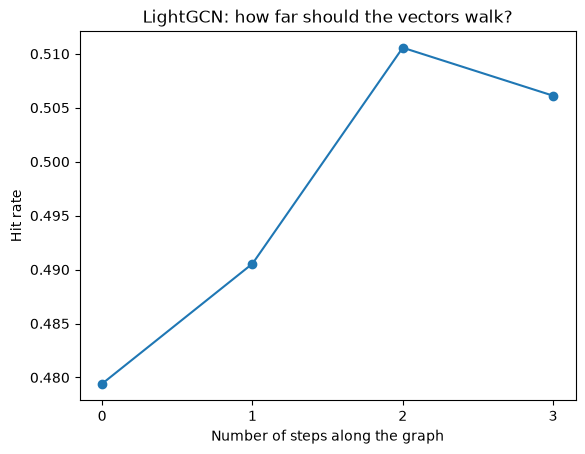

In [15]:
import matplotlib.pyplot as plt

step_counts = [0, 1, 2, 3]
hit_rates = []
for steps in step_counts:
    torch.manual_seed(21)
    model = LightGCN(steps)
    train(model)
    hit_rates.append(evaluate(recommender(model)))
    print(f"Steps: {steps}, hit rate: {hit_rates[-1]:.3f}")

plt.plot(step_counts, hit_rates, marker="o")
plt.xticks(step_counts)
plt.xlabel("Number of steps along the graph")
plt.ylabel("Hit rate")
plt.title("LightGCN: how far should the vectors walk?")
plt.show()

With 0 steps, the vectors stay where they are: no walk at all. Each step adds a bit, and 2 steps give the best score. At 3 steps, the score stops improving: the vectors walk so far that each user starts to receive a bit of everybody.

One training is a bit noisy: with other random starting vectors, the same model got 0.513 in chapter 4. But the gain of the walk holds whatever the start: about +0.02 with 2 steps.

## The weak spot: newcomers, still

The graph only knows the likes. A newcomer without any like has no line: nothing walks to them, and their vector stays the random one we started with. The same goes for a new film. This is the **cold start** problem.

The cure is to use what we know besides the likes: the context of a new user, like their country or their device (chapter 1), the genres of a new film (chapter 2), the profile a user fills in when they sign up (chapter 4). Each recommender we built is good at something different.

## In summary

| Recommender | Uses | Hit rate |
|---|---|---|
| Random | nothing | 0.034 |
| Popular | everybody's likes | 0.346 |
| 40 nearest neighbors (chapter 3) | the most similar users | 0.518 |
| Two towers, IDs only (chapter 4) | a learned vector per user and per film | 0.513 |
| SASRec (chapter 5) | the last 20 films, in order | 0.525 |
| Walks | 3 steps along the likes | 0.395 |
| Fair walks | 3 steps, busy nodes speak softer | 0.476 |
| LightGCN | learned vectors, 2 steps along the likes | 0.511 |

A graph is another way to look at the likes table: users and films are the nodes, and every like is a line between them. Walking three steps along these lines already recommends well, as long as the busy users and the popular films speak softer. LightGCN goes further: it learns a vector for every node, and lets these vectors walk the graph, so that each user also receives what their neighbors' neighbors liked.

We now have a whole toolbox: popular films, genres, neighbors, towers, sequences, graphs. On a real platform, we do not pick one: we use several of them together. A few fast recommenders bring out hundreds of good candidates, then a more careful model sorts them. That is the idea of our next chapter: **retrieval and ranking**.